# **EXPERIMENT-12**  
**AIM:**

To implement and evaluate a Hidden Markov Model using the hmmlearn library for sequential pattern recognition and analyze hidden state sequences using decoding, posterior probabilities, sequence likelihood, and sample generation.

**Hidden Markov Model – Overview**

A Hidden Markov Model (HMM) is a probabilistic model used for sequential data.
It assumes:
 * The system moves through hidden states
 * Each hidden state produces observable outputs

The model is defined as:

     𝜆=(𝜋,𝐴,𝐵)
Where:
 * π → Initial state probability
 * A → Transition probability matrix
 * B → Emission probability matrix

 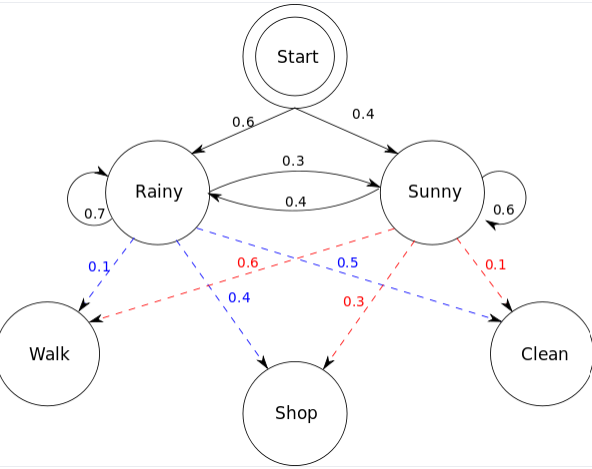

**Step 1 — Hidden States and Observations**
* Hidden states (not directly visible)
  * Rainy  
  * Sunny

* Observations (visible activities)
  * Walk
  * Shop
  * Clean

We only observe activities, and the model infers the hidden weather state.

**Step 2 — Initial Probabilities**

Since the image does not specify them, we assume equal probability.

          π=[0.5,0.5]
Meaning:
  * P(Rainy) = 0.5
  *  P(Sunny) = 0.5

**Step 3 — Transition Probability Matrix**

Rows → Current state
Columns → Next state

    A=     [0.7  0.3]
           [0.4  0.6]
Meaning:
 * Rainy → Rainy = 0.7
 * Rainy → Sunny = 0.3
 * Sunny → Rainy = 0.4
 * Sunny → Sunny = 0.6

**Step 4 — Emission Probability Matrix**
* Rows → Hidden states
* Columns → Observations

Observations mapping:
 * Walk = 0
 * Shop = 1
 * Clean = 2

       B=[ 0.1  0.4  0.5]
         [0.6  0.3  0.1 ]

Meaning:
 * If state = Rainy

    * Walk = 0.1
    * Shop = 0.4
    * Clean = 0.5
* If state = Sunny

    * Walk = 0.6
    * Shop = 0.3
    * Clean = 0.1

In [ ]:
# Step 5 — Install hmmlearn in Colab
!pip install hmmlearn

In [ ]:
#Import Libraries
import numpy as np
from hmmlearn import hmm

**Step 6 — Build HMM with Fixed Parameters**
* hmm.MultinomialHMM(...): This class implements a Hidden Markov Model where the emissions (observations) follow a multinomial distribution, suitable for data like words in a sentence or discrete, counted events.
* n_components=2: Defines that there are 2 hidden states (latent states) in the system
* n_trials=1:Number of trials in the multinomial emission. Simple Terms: It treats each observation as a single event (like flipping a coin once). This is standard for categorical data (e.g., for each time step, you observe one "item").
* init_params="": Tells the model not to initialize any parameters automatically (like starting probabilities, transition matrix, or emission probabilities) before training.Simple Terms: An empty string ("") means do not automatically guess the starting probabilities, transition probabilities, or emission probabilities. It expects you to provide these values yourself before fitting the model.
* params="": Specifies that no parameters should be updated during the .fit() process.Simple Terms: An empty string ("") means do not change any parameters during training. The model will keep the parameters exactly as you initialized them.

In [ ]:
model = hmm.MultinomialHMM(
    n_components=2,
    n_trials=1,
    init_params="",
    params=""
)

https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340


**Set Transition Matrix:**

In [ ]:

model.transmat_ = np.array([
    [0.7, 0.3],
    [0.4, 0.6]
])

**Set Initial Probabilities:**


In [ ]:
model.startprob_ = np.array([0.5, 0.5]) #This attribute defines the Initial State Probability Vector


**Set Emission Matrix:**
The values in the array are interpreted as follows:

* model.emissionprob_[i, j] is the probability of observing output j when the system is in hidden state i.
* Each row sums to 1, as it represents the complete probability distribution of all possible observations for a single hidden state.

In [ ]:
model.emissionprob_ = np.array([
    [0.1, 0.4, 0.5],
    [0.6, 0.3, 0.1]
])

**Step 7 — Example Observation Sequence**

Example activities:
    Walk, Shop, Clean

Convert to numeric form:

    Walk = 0
    Shop = 1
    Clean = 2

In [ ]:
observations = np.array([
    [1,0,0],  # col 1 Walk
    [0,1,0],  # col 2 Shop
    [0,0,1]   # col 3 Clean
])

**Decode Most Likely Hidden States (Viterbi):**
The Viterbi algorithm finds the most probable sequence of hidden states that
produced the observed sequence.
* decode(): This method implements a decoding algorithm to infer hidden information from observed data.
* algorithm="viterbi": This parameter specifies that the Viterbi algorithm should be used for the decoding process. The Viterbi algorithm is a dynamic programming approach to find the single most likely sequence of hidden states for a given sequence of observations.

In [ ]:
logprob, states = model.decode(observations, algorithm="viterbi")

print("Log Probability:", logprob)
print("Most Likely Hidden States:", states)

Log Probability: -4.086376392572924
Most Likely Hidden States: [1 0 0]


**Posterior Probability of States:**
This calculates the probability of being in each hidden state at each time step.

**Why prior:** In Bayesian terms, this is the "posterior probability"—the updated probability of an event happening after observing new data (the observations)

In [ ]:
posterior = model.predict_proba(observations)

print("Posterior probabilities:\n", posterior)

Posterior probabilities:
 [[0.16739747 0.83260253]
 [0.60768636 0.39231364]
 [0.86149084 0.13850916]]


**Sequence Likelihood:**
This computes:   P(O∣λ)  the probability of observing the sequence given the model.

In [ ]:
likelihood = model.score(observations)

print("Sequence Likelihood:", likelihood)

Sequence Likelihood: -3.2501085272992993


**Generate Sample Sequence:**
This generates:
 * sample observation sequence
 * corresponding hidden states

from the trained HMM.

In [ ]:
X, Z = model.sample(5)

print("Generated Observations:", X)
print("Generated Hidden States:", Z)

Generated Observations: [[0 0 1]
 [1 0 0]
 [1 0 0]
 [0 1 0]
 [0 0 1]]
Generated Hidden States: [0 0 1 0 1]


**Conclusion:**

In this experiment, a Hidden Markov Model was implemented using the hmmlearn library for sequential pattern recognition. The model was defined using hidden states, transition probabilities, emission probabilities, and initial state probabilities. The Viterbi algorithm was used to decode the most likely hidden state sequence. Posterior state probabilities and sequence likelihood were computed, and sample sequences were generated from the model.


The experiment shows that the Hidden Markov Model can estimate hidden states from observations and analyze sequence patterns.



